## Chipset Dataset - Data preprocessing practicum

### 1. Problem Statement

Can we predict how much power a chipset will consume  given the design specifications-die size, transistor count, make etc?

In [88]:
# import necessary libraries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [89]:
# Load the dataset
data=pd.read_csv(r'D:\Machine_Learning_Foundations\datasets\chip_dataset (1).csv')
data.head()

,Product,Type,Release Date,Process Size (nm),TDP (W),Die Size (mm^2),Transistors (million),Freq (GHz),Foundry,Vendor,FP16 GFLOPS,FP32 GFLOPS,FP64 GFLOPS
0,AMD Athlon 1000,CPU,6/5/00,180,54,120,37,1000.0,NaN,AMD,NaN,NaN,NaN
1,AMD Athlon 1000,CPU,10/31/00,180,54,120,37,1000.0,NaN,AMD,NaN,NaN,NaN
2,AMD Athlon 1100,CPU,8/14/00,180,60,120,37,1100.0,NaN,AMD,NaN,NaN,NaN
3,AMD Athlon 1133,CPU,10/31/00,180,63,120,37,1133.0,NaN,AMD,NaN,NaN,NaN
4,AMD Athlon 1200,CPU,10/31/00,180,66,120,37,1200.0,NaN,AMD,NaN,NaN,NaN


In [90]:
data.tail()

,Product,Type,Release Date,Process Size (nm),TDP (W),Die Size (mm^2),Transistors (million),Freq (GHz),Foundry,Vendor,FP16 GFLOPS,FP32 GFLOPS,FP64 GFLOPS
4940,NVIDIA GeForce RTX 3050 6 GB,GPU,NaN,8,80,200,8700,1042.0,Samsung,NVIDIA,6021.0,6021.0,94.08
4941,NVIDIA GeForce RTX 4070 SUPER,GPU,1/8/24,5,220,294,35800,1980.0,TSMC,NVIDIA,35480.0,35480.0,554.40
4942,NVIDIA GeForce RTX 4070 Ti SUPER,GPU,1/8/24,5,285,379,45900,2340.0,TSMC,NVIDIA,44100.0,44100.0,689.00
4943,NVIDIA GeForce RTX 4080 SUPER,GPU,1/8/24,5,320,379,45900,2295.0,TSMC,NVIDIA,52220.0,52220.0,816.00
4944,NVIDIA RTX 5880 Ada Generation,GPU,1/5/24,5,285,609,76300,1155.0,TSMC,NVIDIA,71810.0,71810.0,1122.00


### 2. Data Cleaning

In [91]:
# Step 1- check for data type consistency
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4945 entries, 0 to 4944
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Product                4945 non-null   str    
 1   Type                   4945 non-null   str    
 2   Release Date           4746 non-null   str    
 3   Process Size (nm)      4945 non-null   str    
 4   TDP (W)                4508 non-null   str    
 5   Die Size (mm^2)        4593 non-null   str    
 6   Transistors (million)  4390 non-null   str    
 7   Freq (GHz)             4508 non-null   float64
 8   Foundry                4330 non-null   str    
 9   Vendor                 4945 non-null   str    
 10  FP16 GFLOPS            800 non-null    float64
 11  FP32 GFLOPS            1685 non-null   float64
 12  FP64 GFLOPS            1278 non-null   float64
dtypes: float64(4), str(9)
memory usage: 502.4 KB


We have identified that some numerical features are stored as string- first step is to convert string data type to the appropriate numerical format

In [92]:
data.columns.to_list()

['Product',
 'Type',
 'Release Date',
 'Process Size (nm)',
 'TDP (W)',
 'Die Size (mm^2)',
 'Transistors (million)',
 'Freq (GHz)',
 'Foundry',
 'Vendor',
 'FP16 GFLOPS',
 'FP32 GFLOPS',
 'FP64 GFLOPS']

In [93]:
cols=['Process Size (nm)','TDP (W)','Die Size (mm^2)','Transistors (million)']
data[cols]=data[cols].apply(pd.to_numeric,errors='coerce')

In [94]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4945 entries, 0 to 4944
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Product                4945 non-null   str    
 1   Type                   4945 non-null   str    
 2   Release Date           4746 non-null   str    
 3   Process Size (nm)      4887 non-null   float64
 4   TDP (W)                4054 non-null   float64
 5   Die Size (mm^2)        4229 non-null   float64
 6   Transistors (million)  4139 non-null   float64
 7   Freq (GHz)             4508 non-null   float64
 8   Foundry                4330 non-null   str    
 9   Vendor                 4945 non-null   str    
 10  FP16 GFLOPS            800 non-null    float64
 11  FP32 GFLOPS            1685 non-null   float64
 12  FP64 GFLOPS            1278 non-null   float64
dtypes: float64(8), str(5)
memory usage: 502.4 KB


In [95]:
#Step- Check for missing values
data.isnull().sum()

Product                     0
Type                        0
Release Date              199
Process Size (nm)          58
TDP (W)                   891
Die Size (mm^2)           716
Transistors (million)     806
Freq (GHz)                437
Foundry                   615
Vendor                      0
FP16 GFLOPS              4145
FP32 GFLOPS              3260
FP64 GFLOPS              3667
dtype: int64

<Axes: >

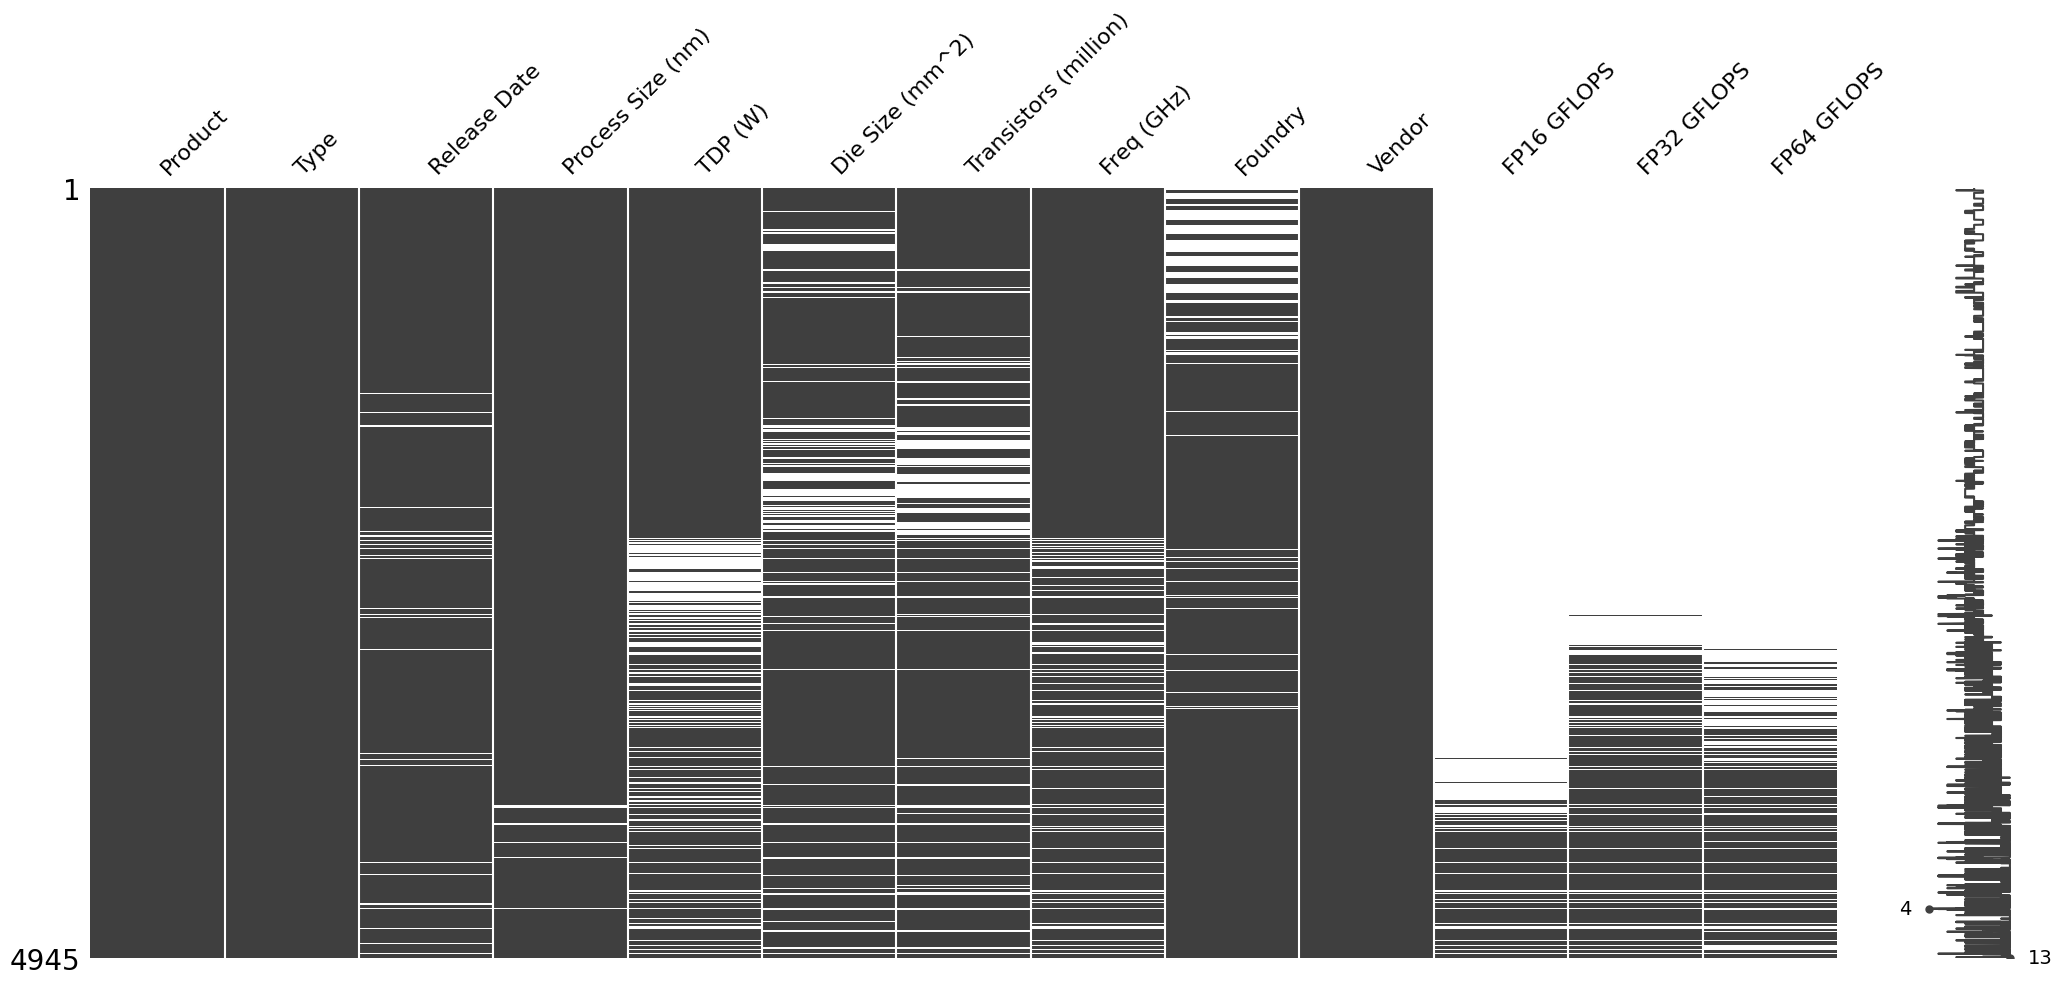

In [96]:
import missingno as mn

mn.matrix(data)

#### Types of Missingness

* Missing Completely at Random
The probability that that data point is missing is totally unrelated to the observed and unobserved data- for example I was filling in a survey and the internet cut off.

* Missing at Random 
The probability that that data point is missing depends on the observed data but not the missing value itself- Men fail to report/answer a question on their mental health status.

* Missing Not at Random
The probability that that data point is misisng depends on the unobserved value - the missing data itself!For example, people with high incomes are less likely to report- survey on incomes.

In [97]:
total_missing=data.isnull().sum().sort_values(ascending=False)
percent=data.isnull().sum().sort_values(ascending=False)/data.isnull().count().sort_values(ascending=False)

missing_df=pd.concat([total_missing,percent],axis=1,keys=['total_missing','percentage_missing'],sort=False)
missing_df.index.name='variable'# set the index name to variable 
missing_df=missing_df[total_missing>0] # only retain those with missing values 
missing_df['percentage_missing']=missing_df['percentage_missing'].map(lambda x:x*100) # convert to percentage 
missing_df

,total_missing,percentage_missing
variable,,
FP16 GFLOPS,4145,83.822042
FP64 GFLOPS,3667,74.155713
FP32 GFLOPS,3260,65.925177
TDP (W),891,18.018200
Transistors (million),806,16.299292
Die Size (mm^2),716,14.479272
Foundry,615,12.436805
Freq (GHz),437,8.837209
Release Date,199,4.024267


In [98]:
data= data.drop(columns=['FP16 GFLOPS', 'FP32 GFLOPS', 'FP64 GFLOPS'])
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4945 entries, 0 to 4944
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Product                4945 non-null   str    
 1   Type                   4945 non-null   str    
 2   Release Date           4746 non-null   str    
 3   Process Size (nm)      4887 non-null   float64
 4   TDP (W)                4054 non-null   float64
 5   Die Size (mm^2)        4229 non-null   float64
 6   Transistors (million)  4139 non-null   float64
 7   Freq (GHz)             4508 non-null   float64
 8   Foundry                4330 non-null   str    
 9   Vendor                 4945 non-null   str    
dtypes: float64(5), str(5)
memory usage: 386.5 KB


In [99]:
data.columns.to_list()

['Product',
 'Type',
 'Release Date',
 'Process Size (nm)',
 'TDP (W)',
 'Die Size (mm^2)',
 'Transistors (million)',
 'Freq (GHz)',
 'Foundry',
 'Vendor']

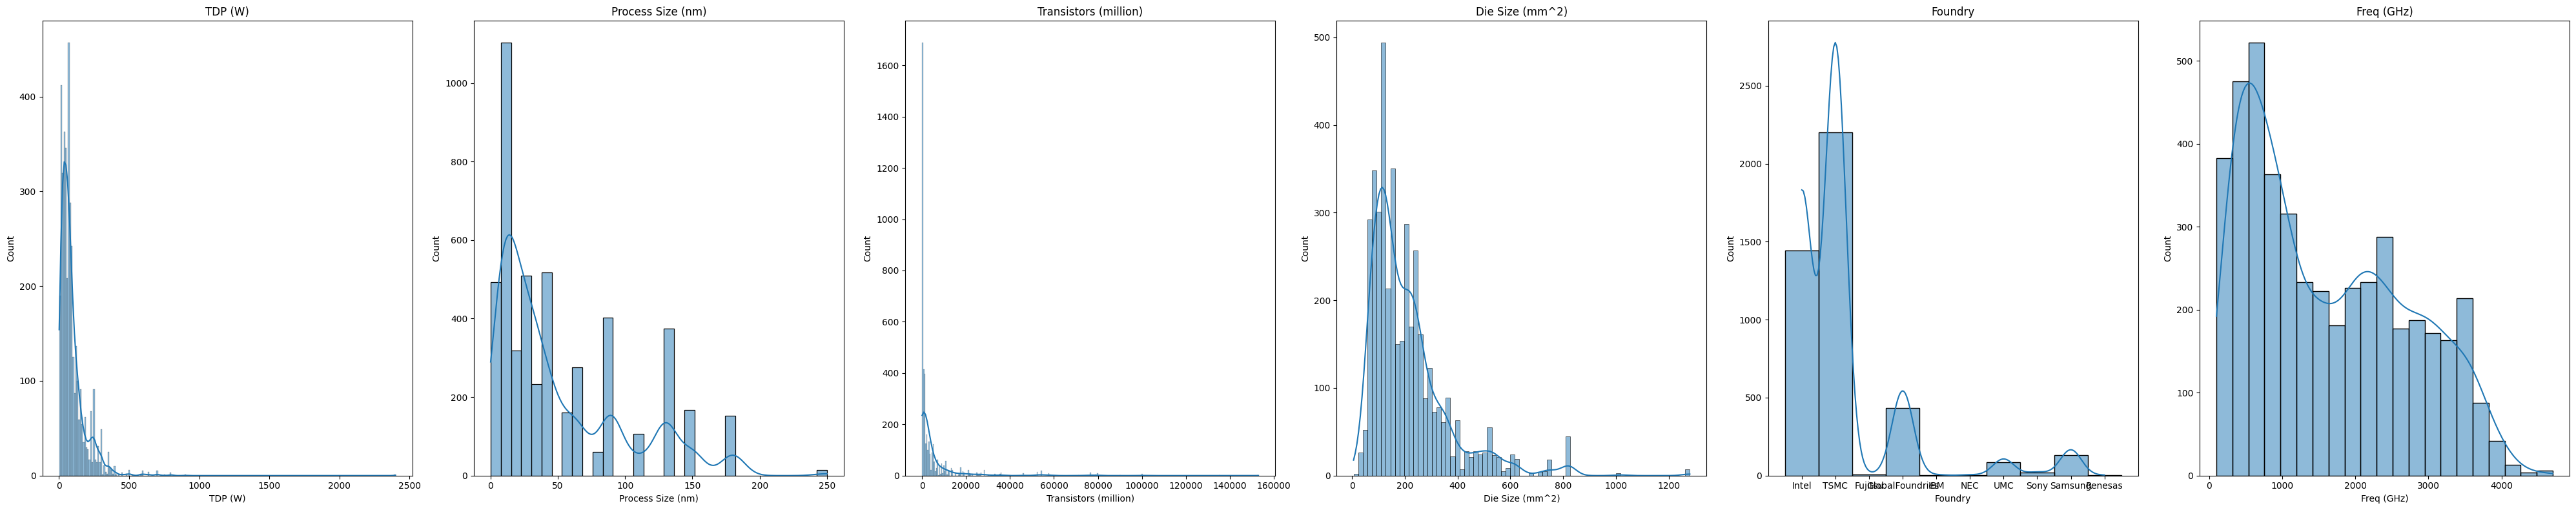

In [100]:
columns_to_plot=['TDP (W)','Process Size (nm)','Transistors (million)',
                 'Die Size (mm^2)','Foundry','Freq (GHz)']
fig = plt.figure(figsize=(40,8))
for i, column in enumerate(columns_to_plot):
    ax = fig.add_subplot(1, 6, i + 1)  
    sns.histplot(data[column],ax=ax,kde=True)
    ax.set_title(column)
plt.tight_layout()
plt.show()

In [101]:
# imputing numerical features with median value
# separate original dataframe into numerical and categorical dataframes


num_df=data.select_dtypes(include=np.number)

from sklearn.impute import SimpleImputer

imputer=SimpleImputer(missing_values=np.nan,strategy='median')
imputer=imputer.fit(num_df)
numerical_imputed=imputer.transform(num_df)
num_df=pd.DataFrame(numerical_imputed,columns=num_df.columns)



In [102]:
# now impute the categorical features with the most frequent value
cat_df=data.select_dtypes(include='object')

imputer=SimpleImputer(missing_values=np.nan,strategy='most_frequent')
imputer=imputer.fit(cat_df)
categorical_imputed=imputer.transform(cat_df)
cat_df=pd.DataFrame(categorical_imputed,columns=cat_df.columns)

C:\Users\Wambui\AppData\Local\Temp\ipykernel_19960\1601083632.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_df=data.select_dtypes(include='object')


In [103]:
clean_data=pd.concat([num_df,cat_df],axis=1)
clean_data.isnull().sum()

Process Size (nm)        0
TDP (W)                  0
Die Size (mm^2)          0
Transistors (million)    0
Freq (GHz)               0
Product                  0
Type                     0
Release Date             0
Foundry                  0
Vendor                   0
dtype: int64

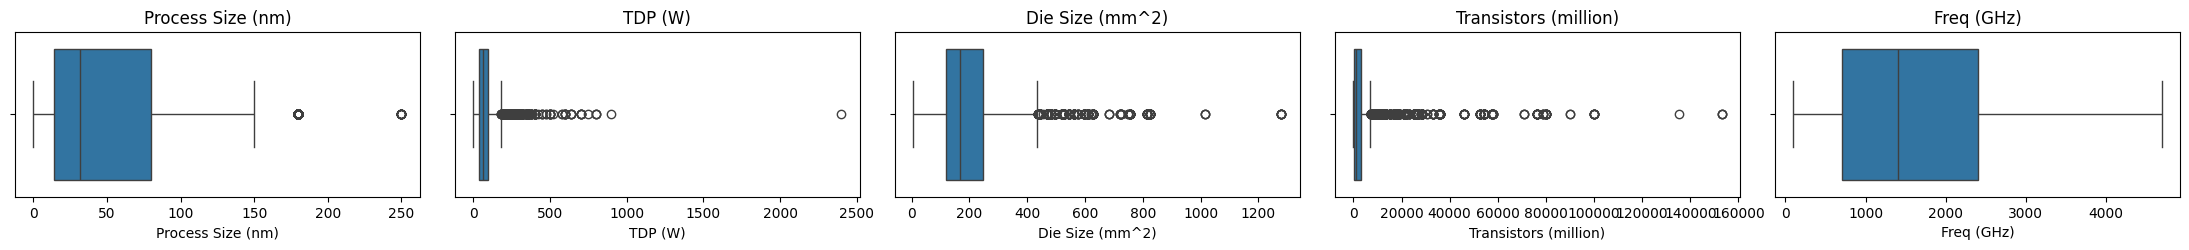

In [104]:
fig = plt.figure(figsize=(22,20))
for i in range(len(num_df.columns)):
    ax=fig.add_subplot(9, 5, i+1)
    sns.boxplot(x=num_df.iloc[:, i],ax=ax)
    ax.set_title(num_df.columns[i])
plt.tight_layout()
plt.show()

In [105]:
#  We also have release date, which is temporal- convert to datetime object
clean_data['Release Date']=pd.to_datetime(data['Release Date'],errors='coerce')
clean_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4945 entries, 0 to 4944
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Process Size (nm)      4945 non-null   float64       
 1   TDP (W)                4945 non-null   float64       
 2   Die Size (mm^2)        4945 non-null   float64       
 3   Transistors (million)  4945 non-null   float64       
 4   Freq (GHz)             4945 non-null   float64       
 5   Product                4945 non-null   str           
 6   Type                   4945 non-null   str           
 7   Release Date           4746 non-null   datetime64[us]
 8   Foundry                4945 non-null   str           
 9   Vendor                 4945 non-null   str           
dtypes: datetime64[us](1), float64(5), str(4)
memory usage: 386.5 KB


C:\Users\Wambui\AppData\Local\Temp\ipykernel_19960\2223690590.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  clean_data['Release Date']=pd.to_datetime(data['Release Date'],errors='coerce')


### 3. Exploratory Data Analysis (EDA)

In [106]:
clean_data.head()

,Process Size (nm),TDP (W),Die Size (mm^2),Transistors (million),Freq (GHz),Product,Type,Release Date,Foundry,Vendor
0,180.0,54.0,120.0,37.0,1000.0,AMD Athlon 1000,CPU,2000-06-05,TSMC,AMD
1,180.0,54.0,120.0,37.0,1000.0,AMD Athlon 1000,CPU,2000-10-31,TSMC,AMD
2,180.0,60.0,120.0,37.0,1100.0,AMD Athlon 1100,CPU,2000-08-14,TSMC,AMD
3,180.0,63.0,120.0,37.0,1133.0,AMD Athlon 1133,CPU,2000-10-31,TSMC,AMD
4,180.0,66.0,120.0,37.0,1200.0,AMD Athlon 1200,CPU,2000-10-31,TSMC,AMD


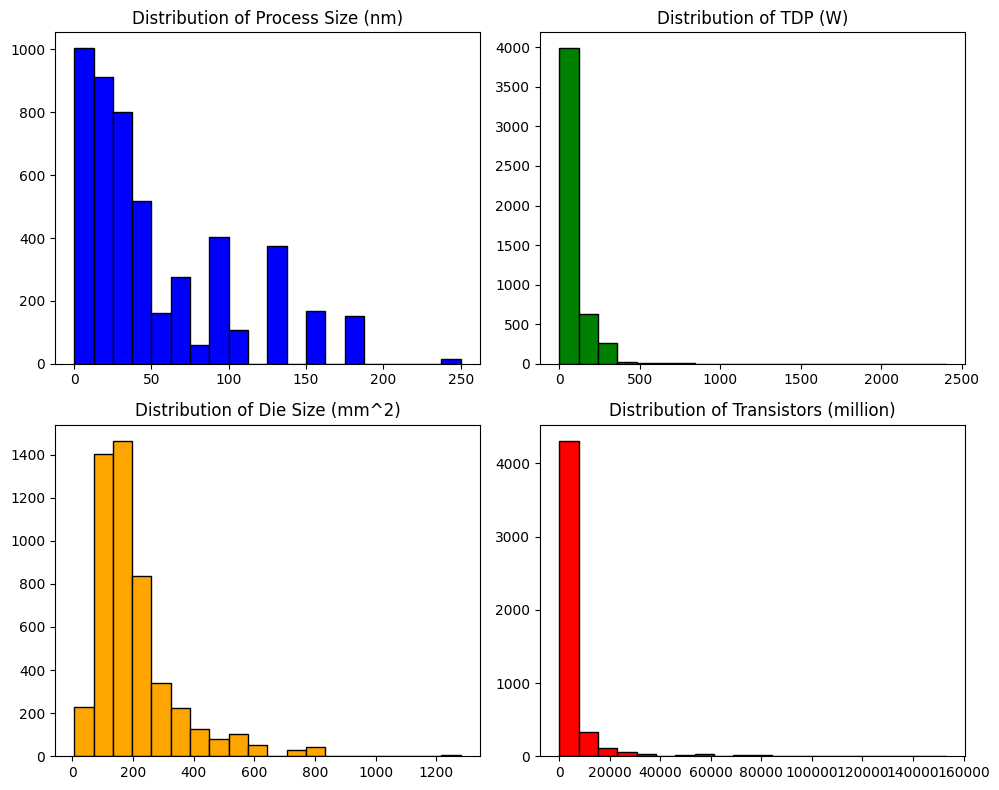

In [107]:
# Distributions of Process size,TDP, die size, transistors

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0,0].hist(clean_data['Process Size (nm)'], bins=20, color='blue', edgecolor='black')
axs[0,0].set_title('Distribution of Process Size (nm)')

axs[0,1].hist(clean_data['TDP (W)'], bins=20, color='green', edgecolor='black')
axs[0,1].set_title('Distribution of TDP (W)')

axs[1,0].hist(clean_data['Die Size (mm^2)'], bins=20, color='orange', edgecolor='black')
axs[1,0].set_title('Distribution of Die Size (mm^2)')   

axs[1,1].hist(clean_data['Transistors (million)'], bins=20, color='red', edgecolor='black')
axs[1,1].set_title('Distribution of Transistors (million)')


plt.tight_layout()
plt.show()

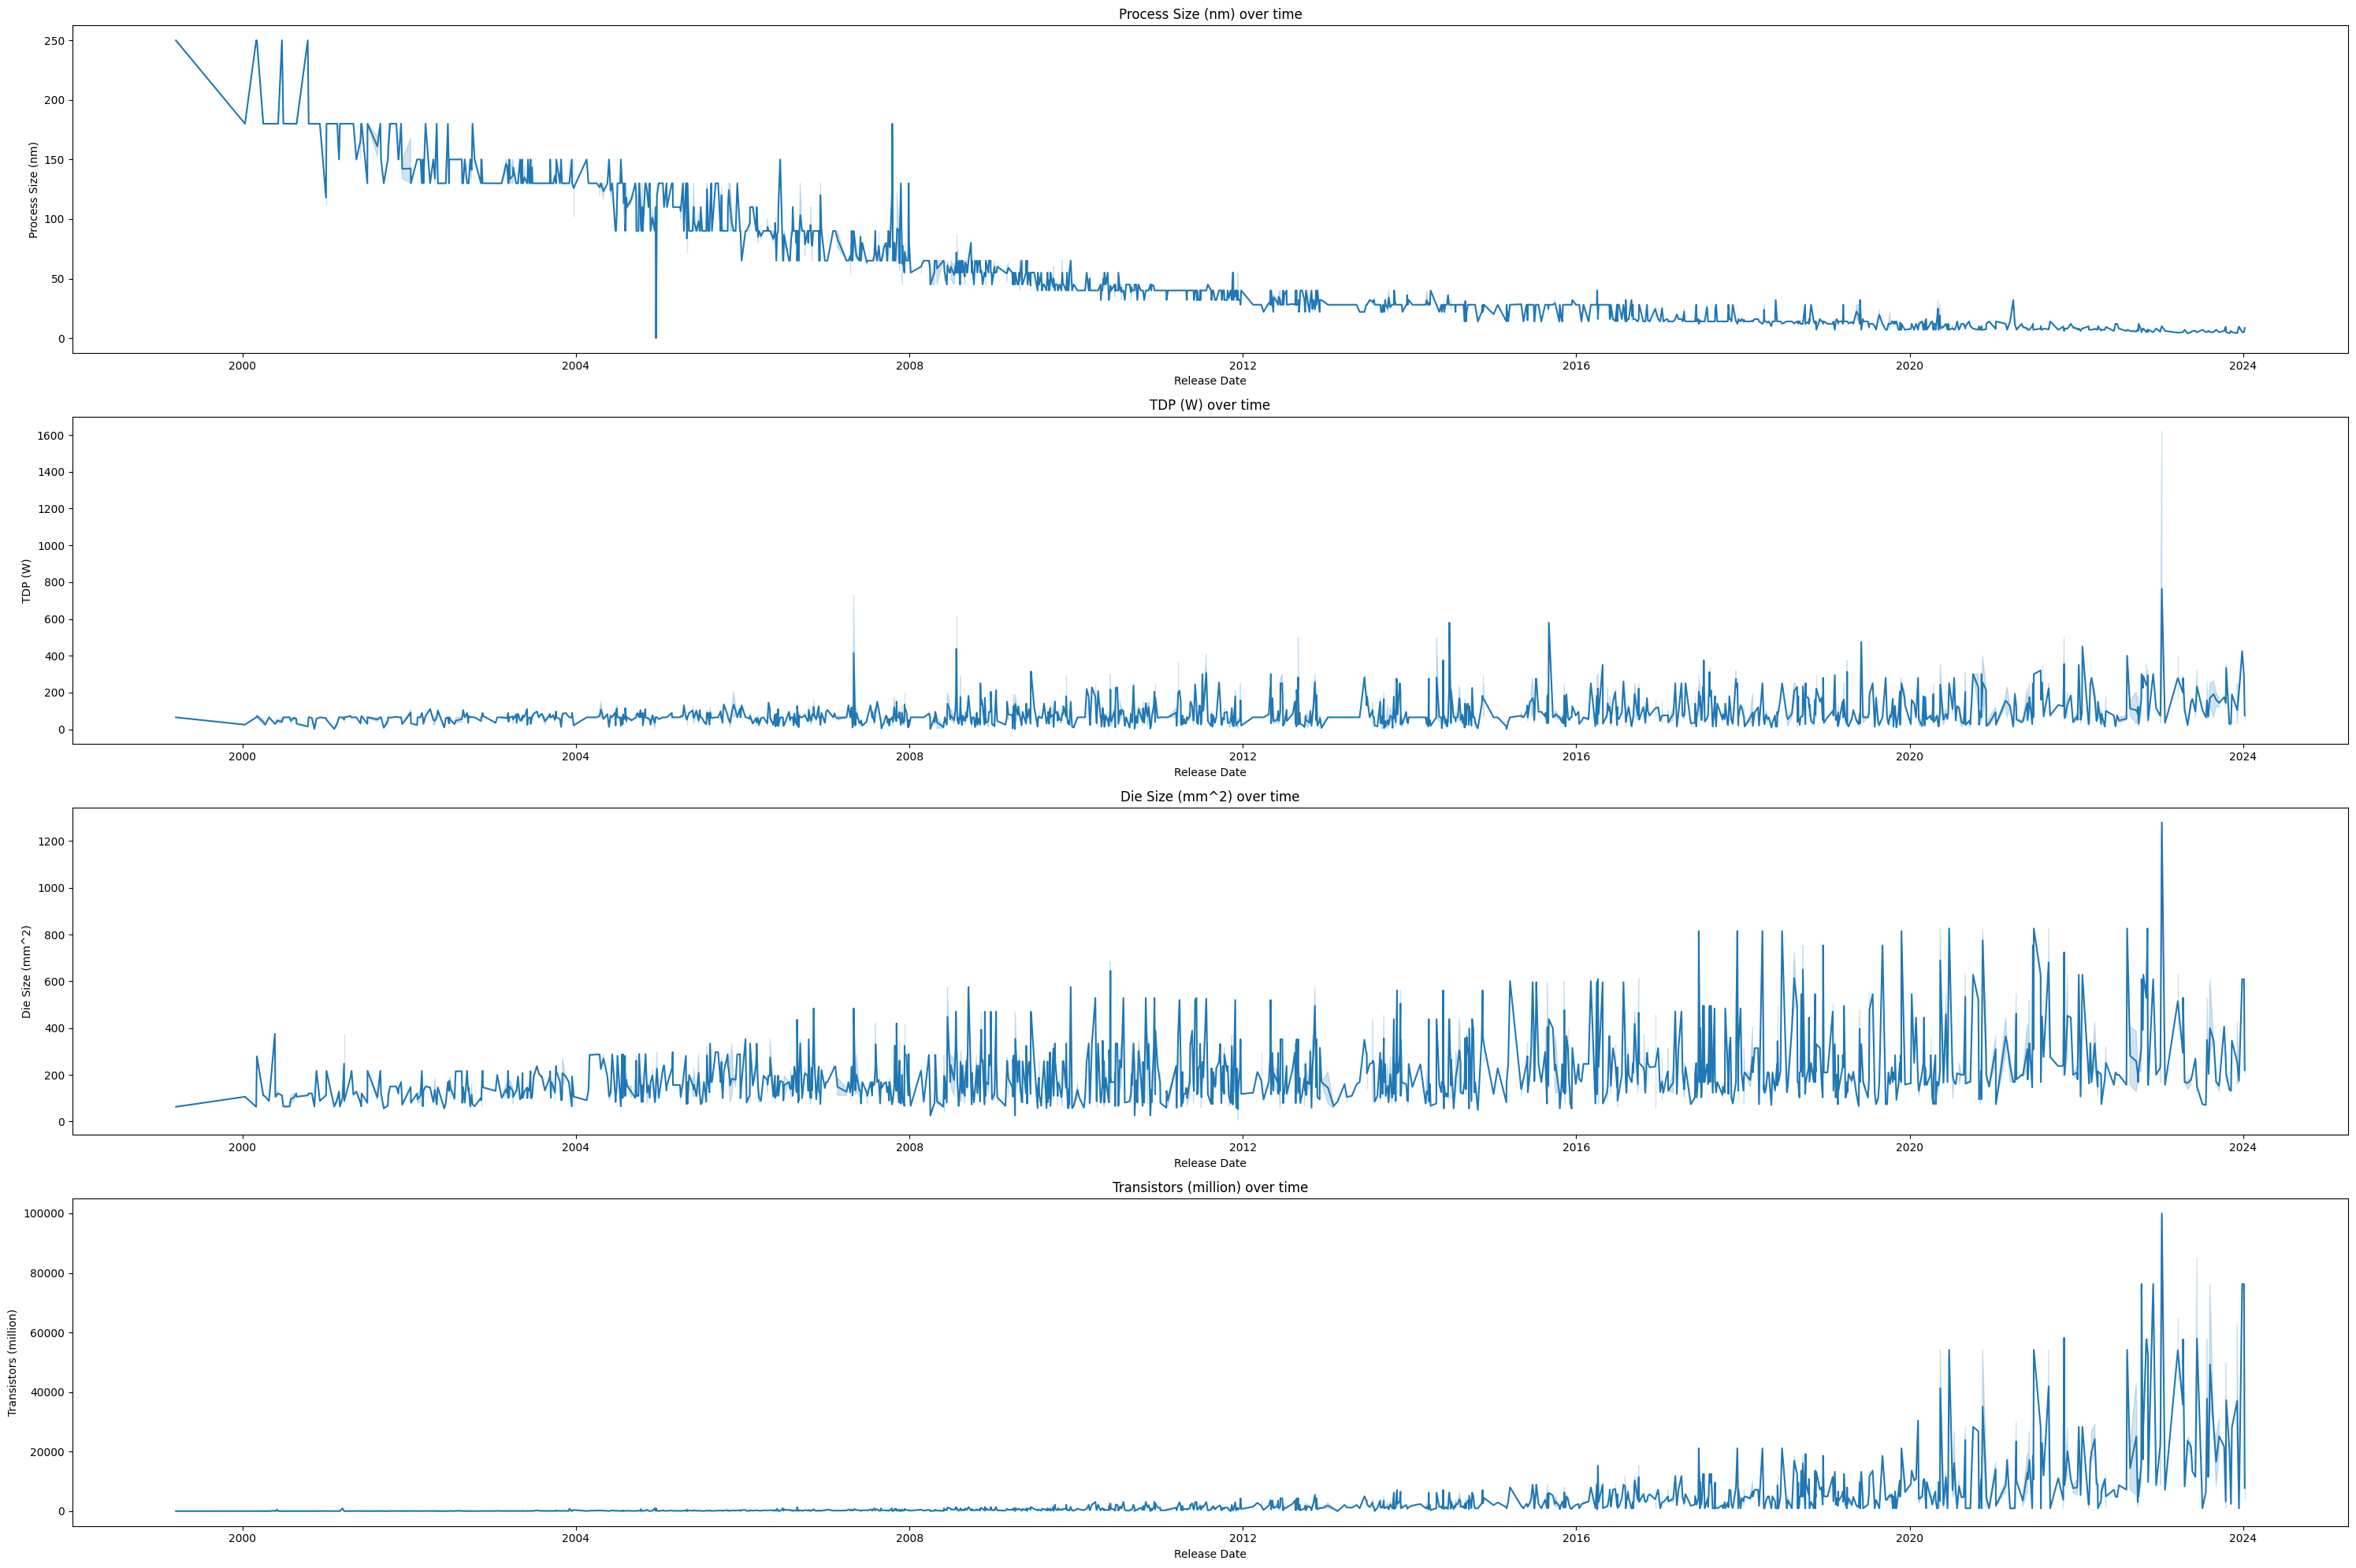

In [108]:
#Let's look at some trends, how have the chipset specifications changed over time

fig, axs = plt.subplots(4,figsize=(30,20))


sns.lineplot(x='Release Date',y='Process Size (nm)',data=clean_data,ax=axs[0])
axs[0].set_title('Process Size (nm) over time')

sns.lineplot(x='Release Date',y='TDP (W)',data=clean_data,ax=axs[1])
axs[1].set_title('TDP (W) over time')

sns.lineplot(x='Release Date',y='Die Size (mm^2)',data=clean_data,ax=axs[2])
axs[2].set_title('Die Size (mm^2) over time')

sns.lineplot(x='Release Date',y='Transistors (million)',data=clean_data,ax=axs[3])
axs[3].set_title('Transistors (million) over time')

plt.tight_layout()
plt.show()

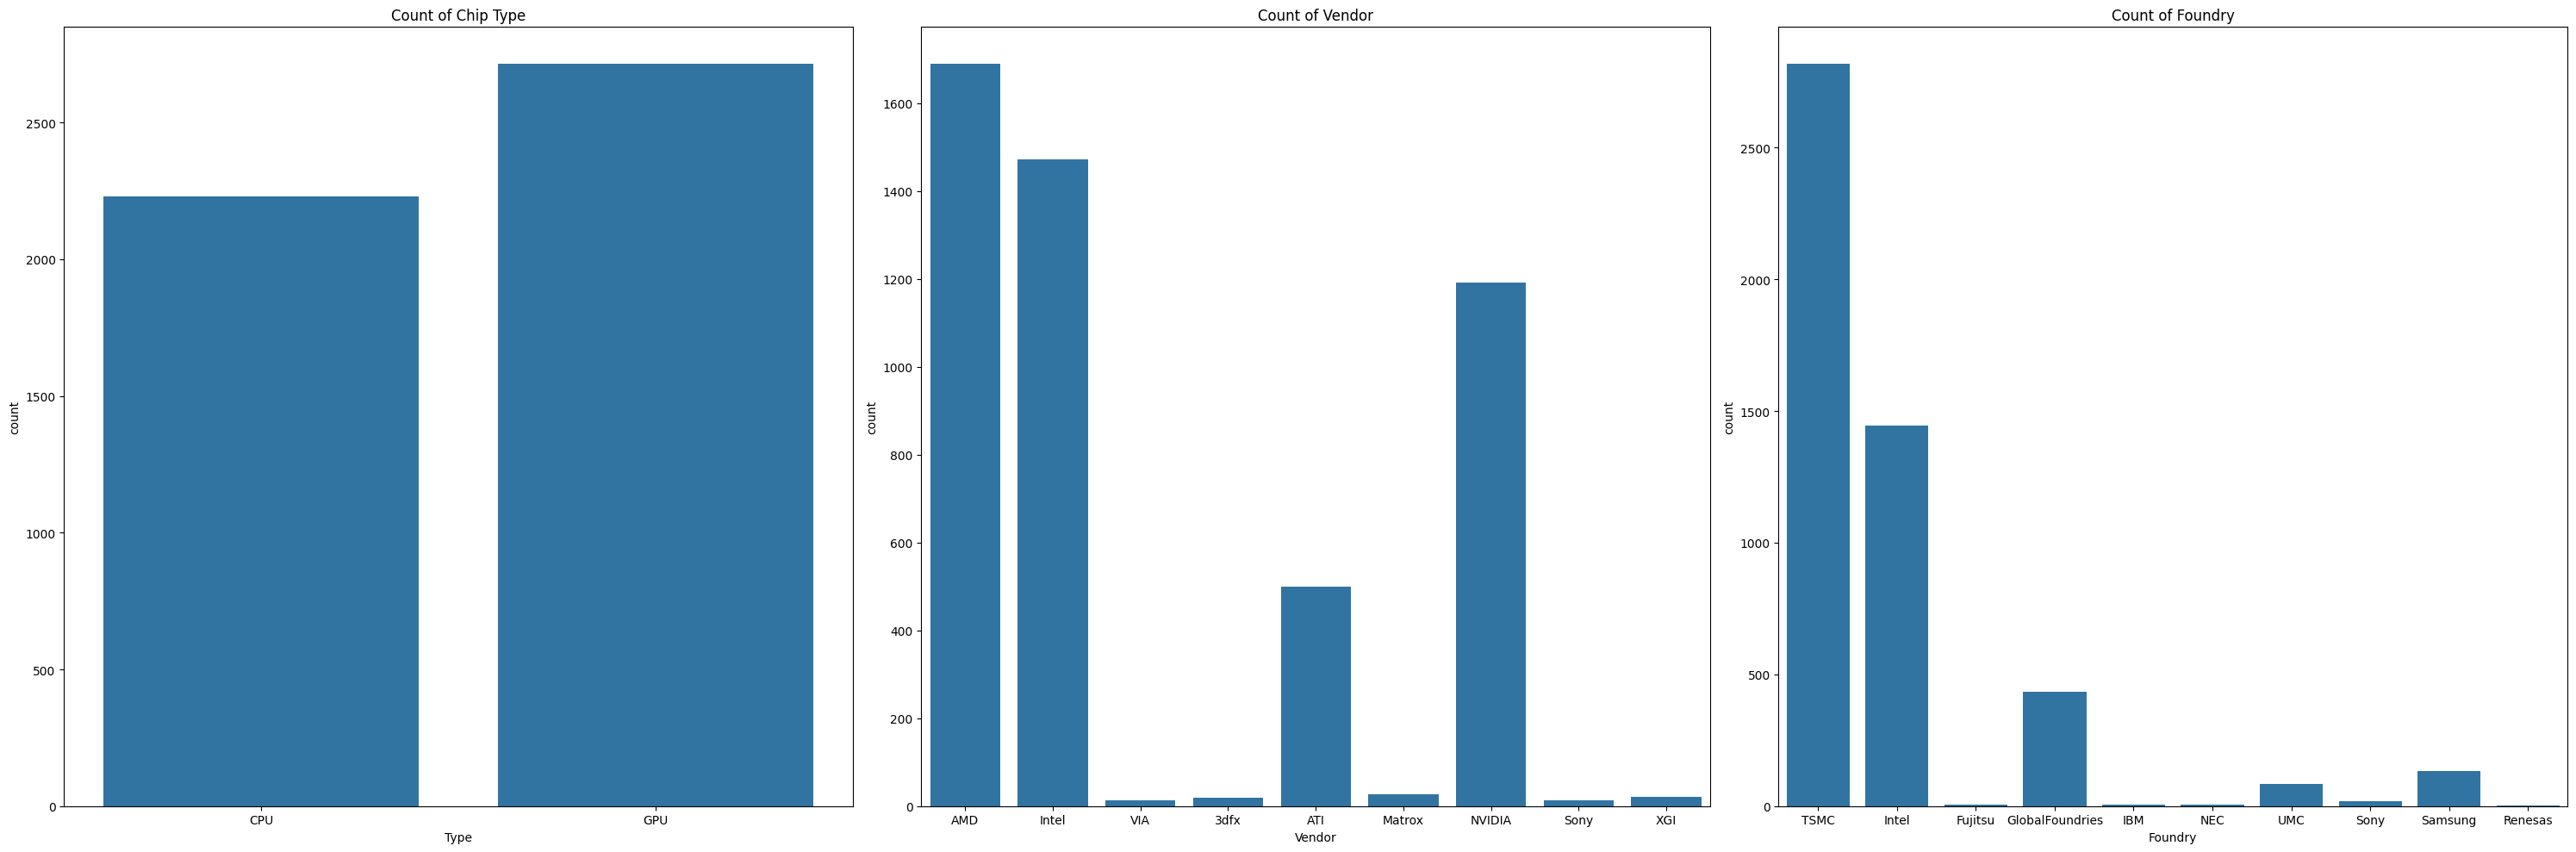

In [109]:
# Then some EDA on the categorical features- type, vendor and foundry...

fig,axs=plt.subplots(1,3,figsize=(30,10))

sns.countplot(x='Type',data=clean_data,ax=axs[0])
axs[0].set_title('Count of Chip Type')   

sns.countplot(x='Vendor',data=clean_data,ax=axs[1])
axs[1].set_title('Count of Vendor')   

sns.countplot(x='Foundry',data=clean_data,ax=axs[2])
axs[2].set_title('Count of Foundry')   

plt.tight_layout()
plt.show()

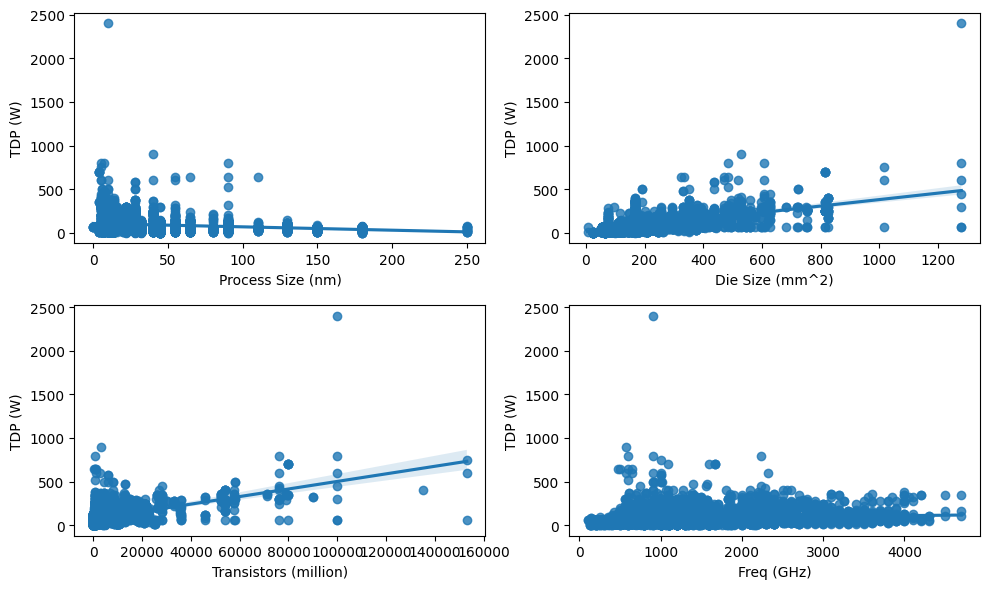

In [110]:
# next, we look at relationships between your input features and your target variable

fig, axs = plt.subplots(2, 2, figsize=(10, 6))

sns.regplot(x='Process Size (nm)',y='TDP (W)',data=clean_data,ax=axs[0,0])
sns.regplot(x='Die Size (mm^2)',y='TDP (W)',data=clean_data,ax=axs[0,1])
sns.regplot(x='Transistors (million)',y='TDP (W)',data=clean_data,ax=axs[1,0])
sns.regplot(x='Freq (GHz)',y='TDP (W)',data=clean_data,ax=axs[1,1])


plt.tight_layout()
plt.show()

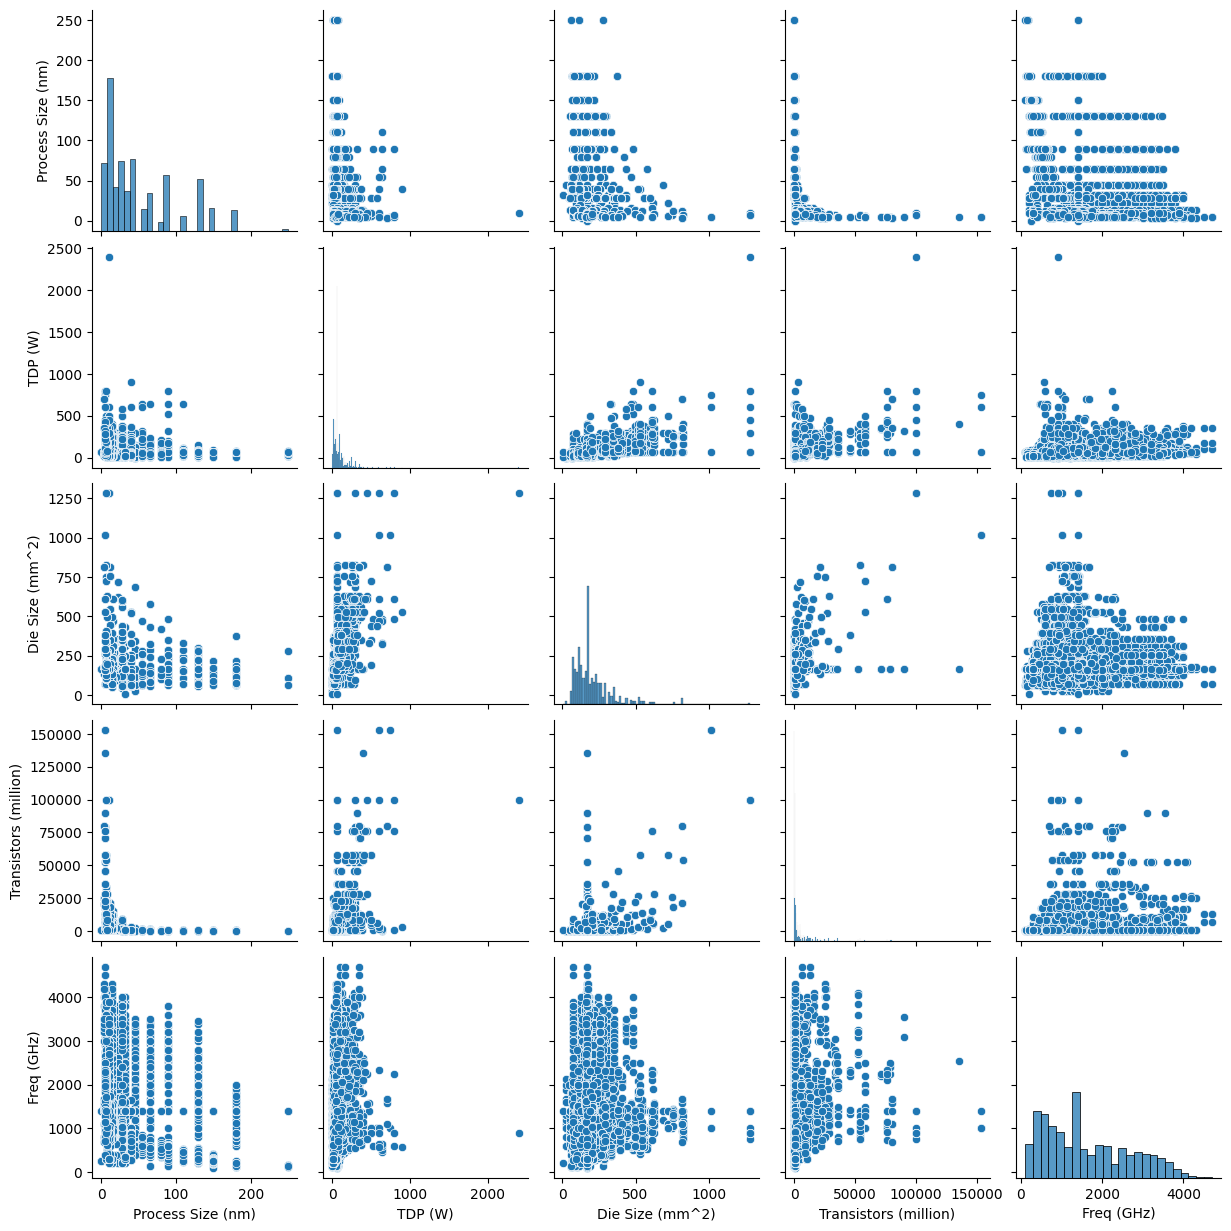

In [111]:
sns.pairplot(clean_data)

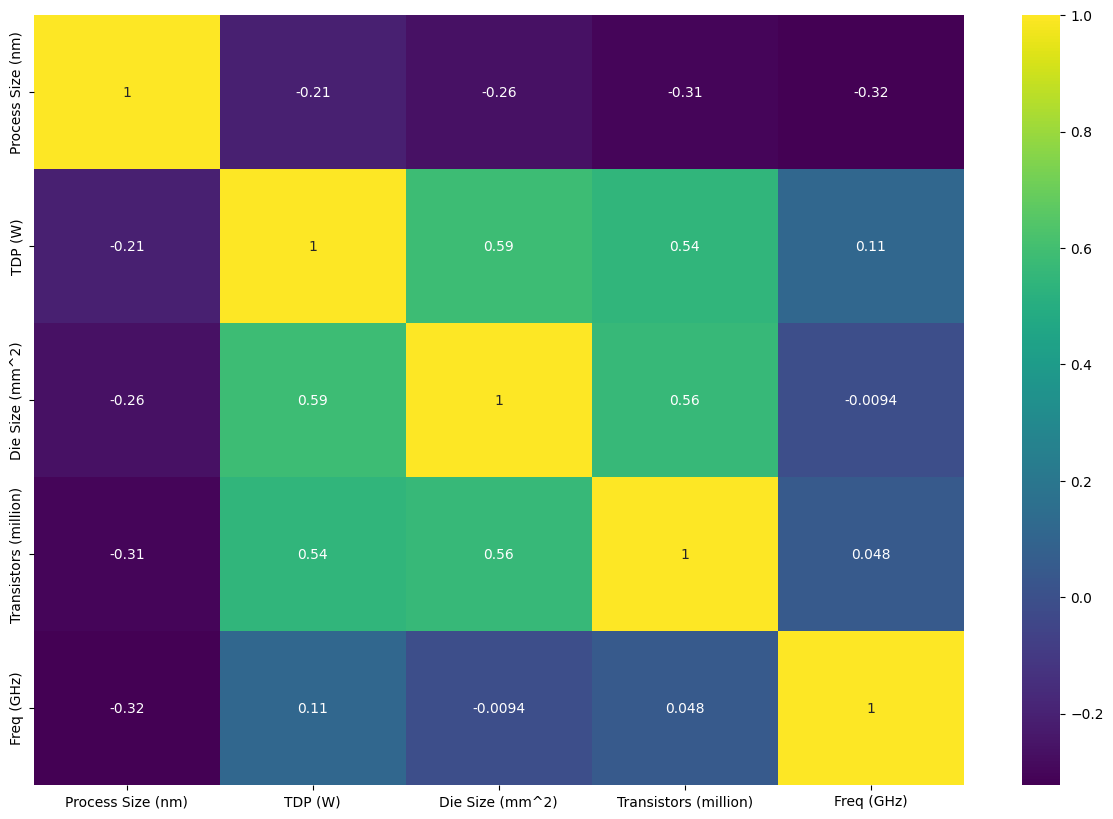

In [112]:
corrmat = num_df.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(15,10))
g=sns.heatmap(num_df[top_corr_features].corr(),annot=True,cmap="viridis")

#### Why do we do EDA in ML
1. Context and model interpretation
2. Feature Selection
2. Identify multi-collinearity 
3. Model selection - linear vs. non-linear models

### 4. Data Proprocessing

### Feature Encoding
A data pre-procesisng step where you transform categorical (non-numeric features) into numeric format.

- One hot encoding
- Count/ Frequency encoding
- Label encoding
- Ordinal encoding
- Target encoding

#### Feature Scaling
Data Transformation step, where you transform numerical features into a standardized range.

- Standardization ( z-score normalization/ Standard scaler): transforms your data to have a mean of 0 and standard deviation of 1- use when your data is normally distributed.

- Normalization (min-max Scaler: transforms your data to be betwene min and max- Use when your data is NOT normally distributed.

- Robust scaling/scaler
- MaxAbs Scaling

#### Feature Engineering
Creating NEW features from your input features...

#### Getting your data ready for modelling- introduction to Model Validation
***What is model validation and its importance?***


Model validation tests how well a machine learning model performs on unseen data. Rather than waiting for new data, we use existing data to evaluate its performance, helping us catch issues before real-world deployment.
There are 2 main model validation techniques, which are further broken down into 12 and each are used depending on the specific machine learning challenge.

![image.webp](..\assets\15eu6sk1xVs3aPGRi6TQW8Q-2048x1326.webp)

#### Machine Learning concepts: The Variance-Bias Tradeoff

The bias-variance tradeoff is a fundamental concept in machine learning that represents the tension between two main sources of prediction error.
##### What is Bias?
Bias measures how far off, on average, a model’s predictions are from the ground truth values. Bias is the error that comes from making overly simple assumptions about your data. A high bias model is an oversimplified model, so much so that it has failed to capture the more complex relationships in the data. We call this ***under-fitting***. The result of this is a model that performs poorly on both the training and testing dataset.

##### What is Variance?
Variance measures how much a model’s predictions change with different training datasets. It comes from fitting very complex models to your data, such that the model ends up learning noise and not the true relationship in the data. We call this ***over-fitting***. The result of this is a model that performs extremely well on the training data and very poorly on the test dataset.

![image.png](..\assets\bias_variance_tradeoff.png)

##### What is the tension then?
The problem is reducing bias, leads to increase in variance and vice versa.

When you make your model more complex to reduce bias, you increase its sensitivity to training data, which increases variance. When you simplify your model to reduce variance, you remove its ability to capture complex patterns, which increases bias.

This inverse relationship is why you can't just minimize both at the same time. Instead, you have to find the balance that gives you the lowest total error- hence the **concept of the bias-variance tradeoff**




##### So how do you diagnose if your model is under fitting or over fitting?

In practice, we identify an overfit or underfit model by plotting and interpretting **learning curves**. This is a plot of training and validation error as a function of training set size or model complexity (e.g., epochs, tree depth, regularization strength).

As a general rule of thumbs, this is how you use this diagnostic tool
 - Under fitting - both high training and validation error
 - Over fitting - high validation error but low training error
 - Good fit - both plots tend to converge

 ![image.png](..\assets\addressing_bias_variance.png)

In [113]:
#Now let's go back to our regression task-predicting TDP
clean_data.head()

,Process Size (nm),TDP (W),Die Size (mm^2),Transistors (million),Freq (GHz),Product,Type,Release Date,Foundry,Vendor
0,180.0,54.0,120.0,37.0,1000.0,AMD Athlon 1000,CPU,2000-06-05,TSMC,AMD
1,180.0,54.0,120.0,37.0,1000.0,AMD Athlon 1000,CPU,2000-10-31,TSMC,AMD
2,180.0,60.0,120.0,37.0,1100.0,AMD Athlon 1100,CPU,2000-08-14,TSMC,AMD
3,180.0,63.0,120.0,37.0,1133.0,AMD Athlon 1133,CPU,2000-10-31,TSMC,AMD
4,180.0,66.0,120.0,37.0,1200.0,AMD Athlon 1200,CPU,2000-10-31,TSMC,AMD


In [114]:
#step one is feature engineering- we can extract year from release data and use that as a feature
clean_data['Release Year']=clean_data['Release Date'].dt.year
clean_data.drop(columns=['Release Date'],inplace=True)    
clean_data.head()

,Process Size (nm),TDP (W),Die Size (mm^2),Transistors (million),Freq (GHz),Product,Type,Foundry,Vendor,Release Year
0,180.0,54.0,120.0,37.0,1000.0,AMD Athlon 1000,CPU,TSMC,AMD,2000.0
1,180.0,54.0,120.0,37.0,1000.0,AMD Athlon 1000,CPU,TSMC,AMD,2000.0
2,180.0,60.0,120.0,37.0,1100.0,AMD Athlon 1100,CPU,TSMC,AMD,2000.0
3,180.0,63.0,120.0,37.0,1133.0,AMD Athlon 1133,CPU,TSMC,AMD,2000.0
4,180.0,66.0,120.0,37.0,1200.0,AMD Athlon 1200,CPU,TSMC,AMD,2000.0


In [117]:
cat_df.drop(columns=['Product'],inplace=True)

In [119]:
cat_df.drop(columns=['Release Date'],inplace=True)

In [120]:
#now we can encode our data
from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)

encoded=ohe.fit_transform(cat_df.astype(str))
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cat_df.columns))
encoded_df.head()


,Type_CPU,Type_GPU,Foundry_Fujitsu,Foundry_GlobalFoundries,Foundry_IBM,Foundry_Intel,Foundry_NEC,Foundry_Renesas,Foundry_Samsung,Foundry_Sony,...,Foundry_UMC,Vendor_3dfx,Vendor_AMD,Vendor_ATI,Vendor_Intel,Vendor_Matrox,Vendor_NVIDIA,Vendor_Sony,Vendor_VIA,Vendor_XGI
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [121]:
#create a final df
final_df=pd.concat([num_df,encoded_df],axis=1)
final_df.head()

,Process Size (nm),TDP (W),Die Size (mm^2),Transistors (million),Freq (GHz),Type_CPU,Type_GPU,Foundry_Fujitsu,Foundry_GlobalFoundries,Foundry_IBM,...,Foundry_UMC,Vendor_3dfx,Vendor_AMD,Vendor_ATI,Vendor_Intel,Vendor_Matrox,Vendor_NVIDIA,Vendor_Sony,Vendor_VIA,Vendor_XGI
0,180.0,54.0,120.0,37.0,1000.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,180.0,54.0,120.0,37.0,1000.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,180.0,60.0,120.0,37.0,1100.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,180.0,63.0,120.0,37.0,1133.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,180.0,66.0,120.0,37.0,1200.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


the next step before modelling is creating the train and test sets..

In [ ]:
#split the data, into input and target variable
X=final_df.drop('TDP (W)',axis=1)
y=final_df[['TDP (W)']]

In [123]:
from sklearn.model_selection import train_test_split, cross_val_score

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=20)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(3956, 25) (989, 25) (3956, 1) (989, 1)


In [124]:
from sklearn.preprocessing import RobustScaler

scaler=RobustScaler()
X_train=scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)